# Análisis de Tendencias en Contrataciones Públicas

#### Carga de las librerías de Python necesarias

In [8]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sqlalchemy import create_engine

## 1. Conexión a SQL Server 

In [72]:
# Configuración de gráficos
plt.rcParams['figure.figsize'] = [12, 8]
pd.options.display.float_format = '{:.2f}'.format

# Crear el engine de SQLAlchemy con pyodbc
conn_str = (
    "mssql+pyodbc://DESKTOP-N55HPMR/I_DE_NEGOCIOS_BD_NUEVO"
    "?driver=ODBC+Driver+17+for+SQL+Server"  # Asegúrate de que esté instalado
    "&trusted_connection=yes"
)
engine = create_engine(conn_str)

## 2. Análisis de Tendencias Temporales

### Consulta a SQL para datos anuales

In [48]:
import pandas as pd

# Consulta SQL para obtener los datos anuales
query_anual = """
SELECT 
    h.año,
    SUM(h.monto_adjudicado_item) AS monto_total,
    COUNT(h.id_hecho) AS cantidad_contratos,
    AVG(h.monto_adjudicado_item) AS monto_promedio
FROM hechos_contrataciones h
GROUP BY h.año
ORDER BY h.año
"""

# Ejecutar consulta y guardar en DataFrame
df_anual = pd.read_sql(query_anual, engine)

# Mostrar los resultados sin formatear
print(df_anual)

      año   monto_total  cantidad_contratos  monto_promedio
0 2020.00 1803016946.87                1246      1447044.10
1 2021.00 3496113337.23                1874      1865588.76
2 2022.00 3539733383.59                1809      1956734.87
3 2023.00 5000766084.63                1690      2959033.19
4 2024.00  723036485.84                  47     15383755.02


### Visualización de tendencias

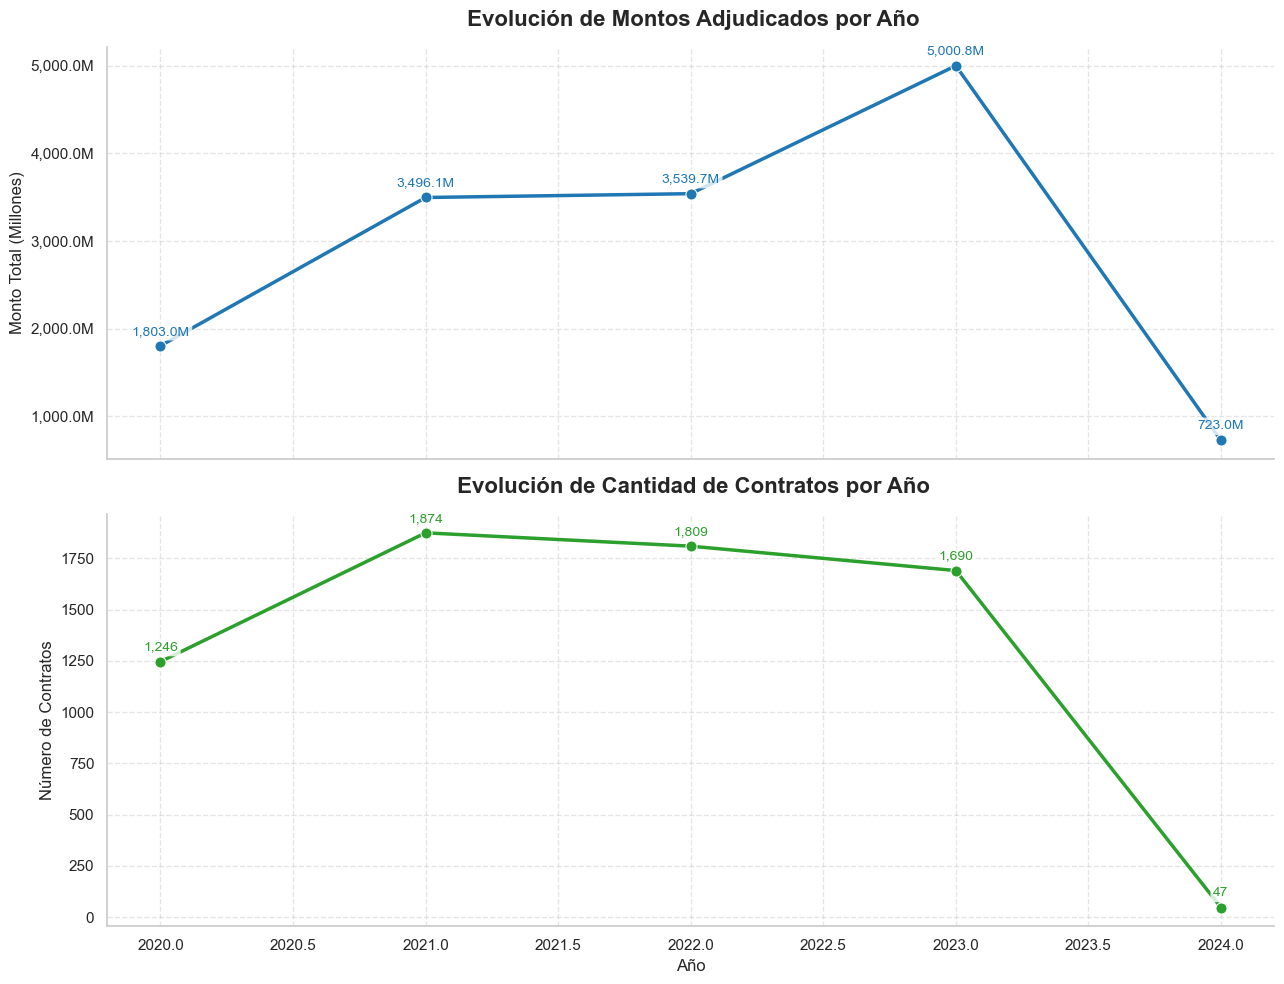

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Estilo elegante
sns.set_theme(style="whitegrid", palette="muted")

# Crear figura con dos ejes verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# --- Gráfico 1: Montos adjudicados ---
sns.lineplot(
    data=df_anual,
    x='año',
    y='monto_total',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#1f77b4',
    ax=ax1
)

# Formatear eje Y en millones con separadores
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))
ax1.set_title(' Evolución de Montos Adjudicados por Año', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Monto Total (Millones)', fontsize=12)
ax1.tick_params(labelsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# Etiquetas de valor
for i, row in df_anual.iterrows():
    ax1.annotate(
        f'{row["monto_total"] / 1e6:,.1f}M',
        xy=(row["año"], row["monto_total"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha='center',
        fontsize=10,
        color='#1f77b4',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8)
    )

# --- Gráfico 2: Cantidad de contratos ---
sns.lineplot(
    data=df_anual,
    x='año',
    y='cantidad_contratos',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#2ca02c',
    ax=ax2
)

ax2.set_title(' Evolución de Cantidad de Contratos por Año', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Número de Contratos', fontsize=12)
ax2.set_xlabel('Año', fontsize=12)
ax2.tick_params(labelsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)

# Etiquetas de valor
for i, row in df_anual.iterrows():
    ax2.annotate(
        f'{int(row["cantidad_contratos"]):,}',
        xy=(row["año"], row["cantidad_contratos"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha='center',
        fontsize=10,
        color='#2ca02c',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8)
    )

plt.tight_layout()
plt.show()

### Prueba estadística de tendencia

In [53]:
from scipy.stats import linregress

def analizar_tendencia(x, y, nombre_variable="Variable"):
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    signo = "📈" if slope > 0 else "📉" if slope < 0 else "➖"
    significativa = p_value < 0.05

    print(f"\n🔍 Análisis de tendencia para: {nombre_variable}")
    print(f"{signo} Pendiente: {slope:,.2f}")
    print(f"🧪 R²: {r_value**2:.4f}")
    print(f"📊 Valor p: {p_value:.4f}")

    if significativa:
        direccion = "positiva" if slope > 0 else "negativa"
        print(f"✅ Tendencia significativa ({direccion})")
    else:
        print("⚠️ No hay evidencia de tendencia significativa")

    print("-" * 40)

# Uso
analizar_tendencia(df_anual['año'], df_anual['monto_total'], "Montos Adjudicados")
analizar_tendencia(df_anual['año'], df_anual['cantidad_contratos'], "Cantidad de Contratos")


🔍 Análisis de tendencia para: Montos Adjudicados
📉 Pendiente: -65,530,817.47
🧪 R²: 0.0039
📊 Valor p: 0.9209
⚠️ No hay evidencia de tendencia significativa
----------------------------------------

🔍 Análisis de tendencia para: Cantidad de Contratos
📉 Pendiente: -258.20
🧪 R²: 0.2888
📊 Valor p: 0.3502
⚠️ No hay evidencia de tendencia significativa
----------------------------------------


## 3. Análisis por Departamento

### Consulta SQL para datos por departamento

In [54]:
query_dept = """
SELECT 
    e.departamento_entidad AS departamento,
    SUM(h.monto_adjudicado_item) AS monto_total,
    COUNT(h.id_hecho) AS cantidad_contratos
FROM hechos_contrataciones h
JOIN dim_entidad e ON h.id_entidad = e.id_entidad
GROUP BY e.departamento_entidad
ORDER BY monto_total DESC
"""

df_dept = pd.read_sql(query_dept, engine)
print(df_dept)

          departamento   monto_total  cantidad_contratos
0                 LIMA 1123970184.81                 601
1                PIURA  831614792.17                 358
2             AREQUIPA  777014035.82                 328
3          LA LIBERTAD  729245896.18                 321
4            CAJAMARCA  710004522.29                 280
5           LAMBAYEQUE  705535770.79                 340
6   MULTIDEPARTAMENTAL  685756638.46                 263
7               ANCASH  676338251.58                 284
8                  ICA  637170182.65                 277
9                CUSCO  607535764.41                 245
10              TUMBES  605556418.69                 238
11                PUNO  584101724.22                 238
12              LORETO  541535826.21                 234
13              CALLAO  519543787.35                 203
14            APURIMAC  515018134.94                 225
15          SAN MARTIN  508955925.39                 244
16               TACNA  4861772

### Visualización top 5 departamentos

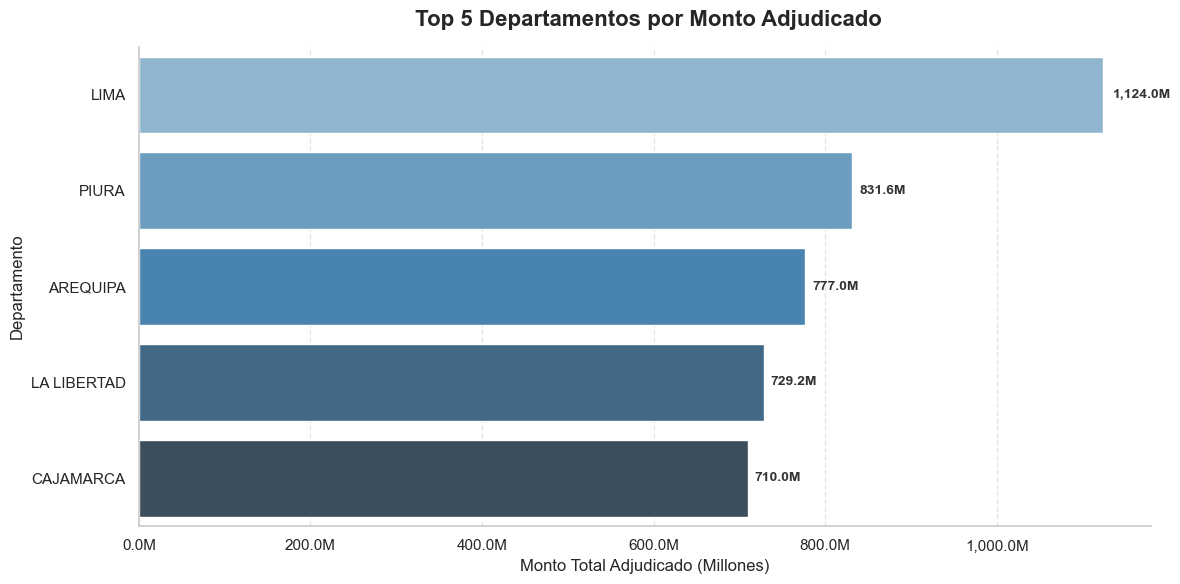

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Filtrar Top 5 departamentos por monto total adjudicado
top5 = df_dept.nlargest(5, 'monto_total').sort_values('monto_total', ascending=False)  # Para orden de abajo hacia arriba

# Estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top5, x='monto_total', y='departamento', hue='departamento', palette='Blues_d', legend=False)

# Formato del eje X en millones con separador de miles
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))

# Título y etiquetas
ax.set_title(' Top 5 Departamentos por Monto Adjudicado', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Monto Total Adjudicado (Millones)', fontsize=12)
ax.set_ylabel('Departamento', fontsize=12)
ax.tick_params(labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Añadir etiquetas al final de cada barra
for i, row in top5.iterrows():
    ax.text(
        row['monto_total'] + (row['monto_total'] * 0.01),  # Desplazamiento a la derecha
        i,
        f"{row['monto_total']/1e6:,.1f}M",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

plt.tight_layout()
plt.show()

## 4. Análisis Mensual (Estacionalidad)

### Consulta SQL para datos mensuales

In [60]:
query_mensual = """
SELECT 
    YEAR(h.fecha_buenapro) AS año,
    MONTH(h.fecha_buenapro) AS mes,
    SUM(h.monto_adjudicado_item) AS monto_total
FROM hechos_contrataciones h
WHERE h.fecha_buenapro IS NOT NULL
GROUP BY YEAR(h.fecha_buenapro), MONTH(h.fecha_buenapro)
ORDER BY año, mes
"""

df_mensual = pd.read_sql(query_mensual, engine)
df_mensual['fecha'] = pd.to_datetime(df_mensual['año'].astype(str) + '-' + df_mensual['mes'].astype(str))
print(df_mensual)

     año  mes   monto_total      fecha
0   2020    1  105431240.86 2020-01-01
1   2020    2    6206189.17 2020-02-01
2   2020    3   20103259.05 2020-03-01
3   2020    4   26852199.60 2020-04-01
4   2020    5   13965760.96 2020-05-01
5   2020    6  167964736.25 2020-06-01
6   2020    7   29914672.38 2020-07-01
7   2020    8   59373079.84 2020-08-01
8   2020    9  386929442.27 2020-09-01
9   2020   10  158480341.24 2020-10-01
10  2020   11  129144520.19 2020-11-01
11  2020   12  234646113.17 2020-12-01
12  2021    1  465015856.34 2021-01-01
13  2021    2   52515749.14 2021-02-01
14  2021    3   88470534.47 2021-03-01
15  2021    4  441284594.06 2021-04-01
16  2021    5  143115490.14 2021-05-01
17  2021    6  723535029.89 2021-06-01
18  2021    7   66952172.96 2021-07-01
19  2021    8 1454264769.12 2021-08-01
20  2021    9   86087656.39 2021-09-01
21  2021   10   80408500.00 2021-10-01
22  2021   11   56315585.19 2021-11-01
23  2021   12  276148405.15 2021-12-01
24  2022    1   30727495.

### Visualización de estacionalidad

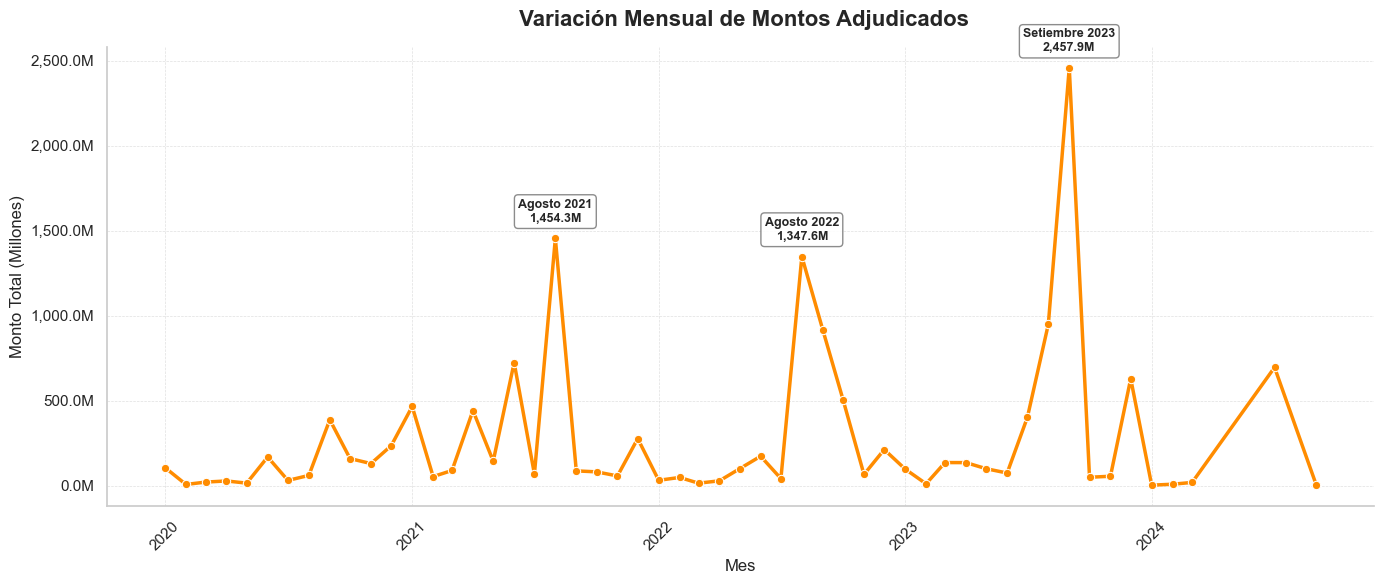

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import locale

# 🌎 Establecer el locale en español (puede variar según sistema operativo)
try:
    locale.setlocale(locale.LC_TIME, 'es_PE.utf8')  # Para sistemas Unix o Linux
except:
    try:
        locale.setlocale(locale.LC_TIME, 'Spanish_Peru.1252')  # Para Windows
    except:
        print("⚠️ No se pudo establecer el locale en español. Se usará el predeterminado.")

# Asegurarse de que 'fecha' esté en formato datetime
df_mensual['fecha'] = pd.to_datetime(df_mensual['fecha'])

# Identificar los 3 picos más altos
top3_picos = df_mensual.nlargest(3, 'monto_total')

# Estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.lineplot(
    data=df_mensual,
    x='fecha',
    y='monto_total',
    marker='o',
    linewidth=2.5,
    color='#FF8C00'
)

# Formato del eje Y en millones
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))

# Título y etiquetas
ax.set_title(' Variación Mensual de Montos Adjudicados', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Monto Total (Millones)', fontsize=12)
ax.tick_params(labelsize=11)
plt.xticks(rotation=45)

# Etiquetas para los 3 picos
for _, row in top3_picos.iterrows():
    fecha = row['fecha']
    monto = row['monto_total']
    etiqueta = f"{fecha.strftime('%B %Y').capitalize()}\n{monto/1e6:,.1f}M"
    ax.annotate(
        etiqueta,
        xy=(fecha, monto),
        xytext=(0, 12),
        textcoords="offset points",
        ha='center',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9)
    )

# Estética final
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Análisis por Tipo de Proveedor

  tipo_proveedor    monto_total  cantidad_contratos
0      Consorcio 14562666238.16                6666


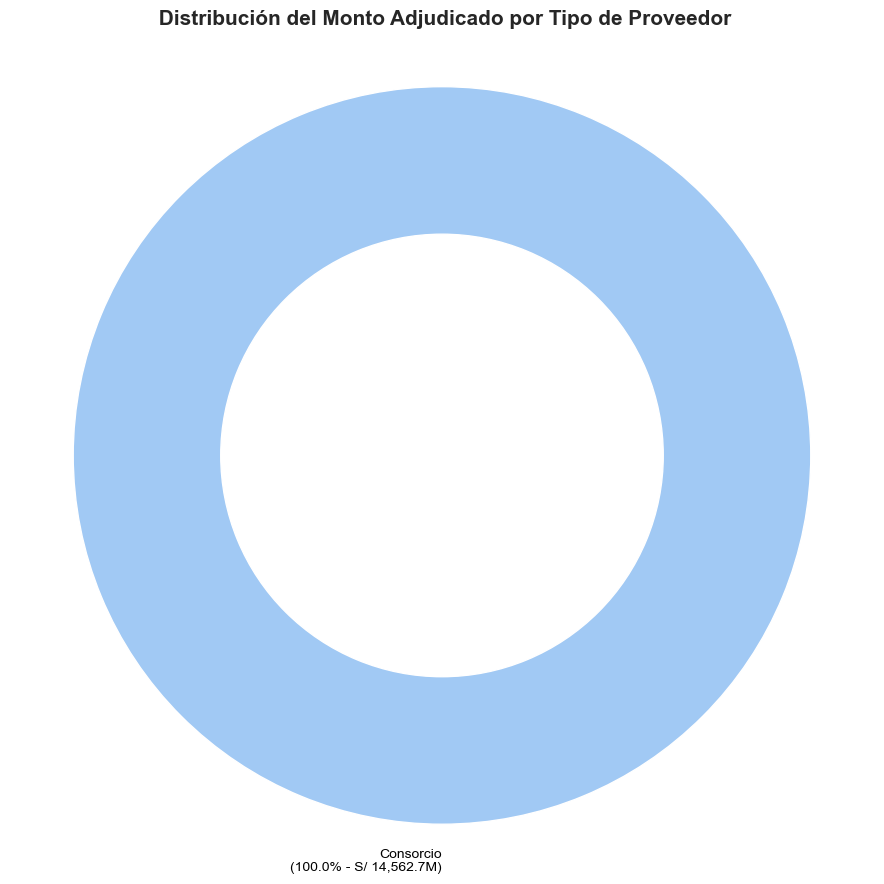

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Leer datos desde SQL
query_proveedor = """
SELECT 
    p.tipo_proveedor,
    SUM(h.monto_adjudicado_item) AS monto_total,
    COUNT(h.id_hecho) AS cantidad_contratos
FROM hechos_contrataciones h
JOIN dim_proveedor p ON h.id_proveedor = p.id_proveedor
GROUP BY p.tipo_proveedor
ORDER BY monto_total DESC
"""

df_proveedor = pd.read_sql(query_proveedor, engine)
print(df_proveedor)
# Preparar datos
df_plot = df_proveedor.copy()
df_plot['porcentaje'] = df_plot['monto_total'] / df_plot['monto_total'].sum()
df_plot = df_plot.sort_values('porcentaje', ascending=False)

# Etiquetas con tipo + porcentaje + monto total
df_plot['etiqueta'] = df_plot.apply(
    lambda row: f"{row['tipo_proveedor']}\n({row['porcentaje']*100:.1f}% - S/ {row['monto_total']/1e6:,.1f}M)", axis=1
)

# Paleta elegante pastel
colors = sns.color_palette('pastel')[:len(df_plot)]

# Crear figura
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts = ax.pie(
    df_plot['monto_total'],
    labels=df_plot['etiqueta'],
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w'),
    textprops=dict(color='black', fontsize=10)
)

ax.set_title(" Distribución del Monto Adjudicado por Tipo de Proveedor", fontsize=15, fontweight='bold', pad=20)
ax.axis('equal')  # Para mantener círculo perfecto
plt.tight_layout()
plt.show()

## Conclusiones

### 1. Evolución Anual de Montos y Contratos
* Hallazgos:
    * Crecimiento irregular: Aumentos significativos en 2021 (+93.8%) y 2023 (+41.3%), pero          sin tendencia estadística significativa (p=0.9209, R²=0.0039).

    * Contratos más grandes: El monto promedio por contrato se triplicó entre 2020 y 2024 (de        1.45M a 15.38M).

    * Reducción en cantidad: La cantidad de contratos cayó un 9.8% desde 2021, aunque no es          estadísticamente significativa (p=0.3502).
 
### 2. Distribución por Departamento
* Patrones Geográficos:
    * Concentración en costa norte: Piura, La Libertad y Cajamarca representan 33.3% del total.
    * Lima domina: Aunque solo tiene el 11.7% de los contratos, concentra el 16.5% del monto.
### 3. Estacionalidad Mensual
* Picos Notables:
    * Agosto 2021: 1,454.3M (mayor adjudicación mensual registrada).
    * Septiembre 2023: 2,457.5M (nuevo récord).
    * Tendencia: Los montos suelen dispararse en Q3 (julio-septiembre), posiblemente por:
        * Cierre de ejercicios fiscales.
        * Ejecución de proyectos priorizados a fin de año.

## Conclusiones Generales
 ### A. Tendencias Clave
    1. Crecimiento volátil, no sostenido:

* Los saltos en 2021 y 2023 sugieren proyectos extraordinarios (no tendencia estructural).

* La falta de significancia estadística (p>0.05) confirma que no hay un patrón claro de crecimiento.

    2. Contratos más grandes, pero menos frecuentes:

* El monto promedio por contrato aumentó 10.6x desde 2020, mientras la cantidad cayó un 62.3%.

    3. Desigualdad territorial:

* Lima y 4 departamentos concentran 61.2% de los recursos, evidenciando desbalance en distribución.

 ### B. Recomendaciones
* Investigación de picos: Analizar qué causó los récords en 2021/2023 (ej.: megaproyectos, cambios normativos).

* Optimizar calendario de licitaciones: Aprovechar la estacionalidad (Q3) para planificar flujos de caja.

* Equilibrio territorial: Revisar criterios de asignación para reducir brechas entre departamentos.

* Monitorear 2024: El alto monto promedio (15.38M) podría indicar una nueva estrategia de contratación.

 ### C. Próximos Pasos
* Segmentar por tipo de proceso (obras vs. servicios) y tipo de proveedor (empresas vs. consorcios).

* Cruzar datos con indicadores socioeconómicos (ej.: pobreza regional) para priorizar inversiones.